### Are Early Industries Quietly Absorbing the Most Layoffs?

Which industries and countries have been hit hardest by tech layoffs, and when did it peak? This project cleans and analyzes the Layoffs dataset using Python and Pandas to find where job losses are concentrated, and to show why percentage laid off and total laid off can tell very different stories about the same event.

Dataset: Layoffs Dataset (Kaggle)
Tools: Python, Pandas, Matplotlib, Seaborn

### Step 1  : Setup

In [15]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

### Step 2 : Loading the Data

In [5]:
df = pd.read_csv(r"E:\tech-layoffs-analysis\data\raw\layoffs.csv")
print(df.shape)
df.head()

(4608, 11)


,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Trustly,"Stockholm, Non-U.S.",200.0,9/17/2026,NaN,Finance,https://tech.eu/2026/09/17/swedish-fintech-tru...,Acquired,28.0,Sweden,9/17/2026
1,Bluevine,"Bengaluru, Non-U.S.",80.0,9/17/2026,NaN,Finance,https://www.ndtv.com/offbeat/team-of-80-indian...,Unknown,769.0,India,9/17/2026
2,Pulley,SF Bay Area,NaN,9/15/2026,1.0,Finance,https://www.businessinsider.com/pulley-shuts-d...,Series B,50.0,United States,9/16/2026
3,Oracle,SF Bay Area,NaN,9/14/2026,NaN,Other,https://www.businessinsider.com/oracle-begins-...,Post-IPO,NaN,United States,9/16/2026
4,Bitcoin Suisse,"Zurich, Non-U.S.",60.0,9/11/2026,0.5,Crypto,https://www.reuters.com/business/world-at-work...,Series A,NaN,Switzerland,9/14/2026


### Step 3 : Initial Audit

In [6]:
print("Dtypes:\n", df.dtypes)
print("\nDuplicate rows (exact):", df.duplicated().sum())
print("\nNulls per column:\n", df.isna().sum())
print("\nSample industry values:\n", df["industry"].unique()[:20])

Dtypes:
 company                    str
location                   str
total_laid_off         float64
date                       str
percentage_laid_off    float64
industry                   str
source                     str
stage                      str
funds_raised           float64
country                    str
date_added                 str
dtype: object

Duplicate rows (exact): 0

Nulls per column:
 company                   0
location                  1
total_laid_off         1598
date                      0
percentage_laid_off    1722
industry                  2
source                    3
stage                     8
funds_raised            549
country                   2
date_added                0
dtype: int64

Sample industry values:
 <StringArray>
[       'Finance',          'Other',         'Crypto',       'Consumer',
       'Hardware',     'Healthcare',      'Marketing',       'Security',
 'Transportation',           'Food',         'Retail',        'Product',
  'Manufa

### Step 4 : Remove duplicates

In [7]:
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} exact duplicate rows. New shape: {df.shape}")

Dropped 0 exact duplicate rows. New shape: (4608, 11)


## Step 5 : Standardize text columns

In [8]:
for col in ["company", "industry", "country", "location", "stage"]:
    df[col] = df[col].where(df[col].notna(), None)
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Check for near-duplicate or inconsistent values before moving on
print(sorted([v for v in df["industry"].unique() if isinstance(v, str)]))
print(sorted([v for v in df["country"].unique() if isinstance(v, str)]))

# Fix the real duplicate found in this dataset: UAE appears as two different values
df["country"] = df["country"].replace({"United Arab Emirates": "UAE"})

['AI', 'Aerospace', 'Construction', 'Consumer', 'Crypto', 'Data', 'Education', 'Energy', 'Finance', 'Fitness', 'Food', 'HR', 'Hardware', 'Healthcare', 'Infrastructure', 'Legal', 'Logistics', 'Manufacturing', 'Marketing', 'Media', 'Other', 'Product', 'Real Estate', 'Recruiting', 'Retail', 'Sales', 'Security', 'Support', 'Transportation', 'Travel']
['Argentina', 'Australia', 'Austria', 'Bahrain', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'Cayman Islands', 'Chile', 'China', 'Colombia', 'Cyprus', 'Czech Republic', 'Denmark', 'Egypt', 'Estonia', 'Finland', 'France', 'Germany', 'Ghana', 'Greece', 'Hong Kong', 'Hungary', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kenya', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Mexico', 'Myanmar', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway', 'Pakistan', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'Saudi Arabia', 'Senegal', 'Seychelles', 'Singapore', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Swit

### Step 6 : Fix the date column

In [9]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
bad_dates = df["date"].isna().sum()
print(f"{bad_dates} rows failed to parse as dates")
df = df.dropna(subset=["date"])  # can't use a row in time-based analysis without a valid date

0 rows failed to parse as dates


### Step 7 :  Handle missing values in the layoff columns

In [10]:
df["percentage_laid_off"] = pd.to_numeric(df["percentage_laid_off"], errors="coerce")

both_missing = df["total_laid_off"].isna() & df["percentage_laid_off"].isna()
print(f"{both_missing.sum()} rows have no layoff numbers at all — dropping these")
df = df[~both_missing]

746 rows have no layoff numbers at all — dropping these


### Step 8 : Drop junk rows

In [11]:
df = df[df["company"].notna() & (df["company"] != "") & (df["company"].str.lower() != "nan")]
print(df.shape)

(3862, 11)


### Step 9 :Industry and month aggregation + Chart 1

industry
Other             116165.0
Retail            108495.0
Hardware          105480.0
Consumer           98654.0
Transportation     71023.0
Finance            66496.0
Food               52501.0
Healthcare         40680.0
Infrastructure     24835.0
Travel             24340.0
Name: total_laid_off, dtype: float64


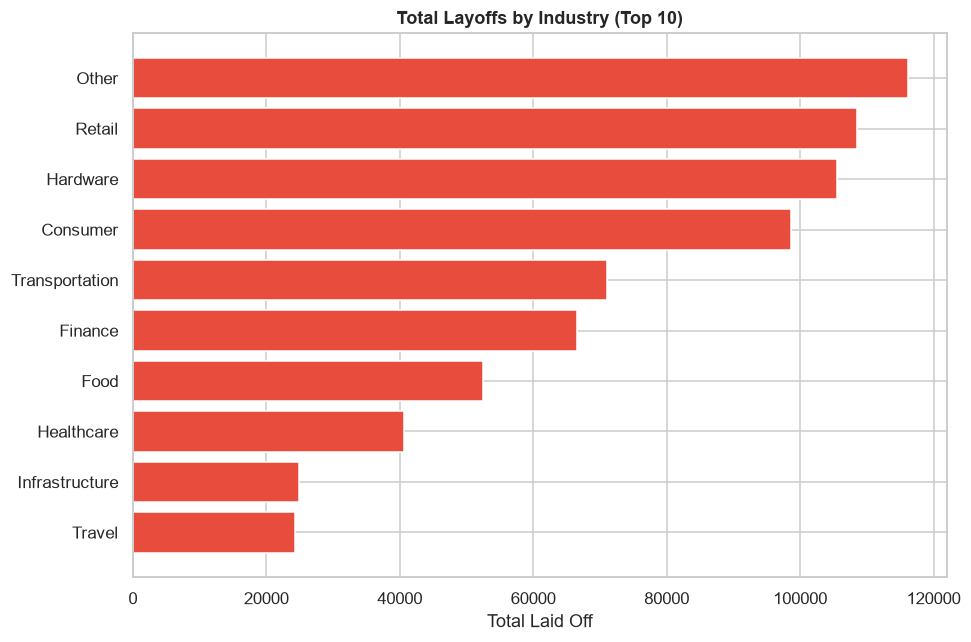

In [12]:
df["month"] = df["date"].dt.to_period("M")

by_industry = (df.groupby("industry")["total_laid_off"].sum()
                 .sort_values(ascending=False).dropna())
print(by_industry.head(10))

top10 = by_industry.head(10)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top10.index[::-1], top10.values[::-1], color="#e74c3c")
ax.set_title("Total Layoffs by Industry (Top 10)", fontweight="bold")
ax.set_xlabel("Total Laid Off")
plt.tight_layout()
plt.savefig("chart1_layoffs_by_industry.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 10 :  Month trend + Chart 2

Peak month: 2023-01, total laid off: 89,709


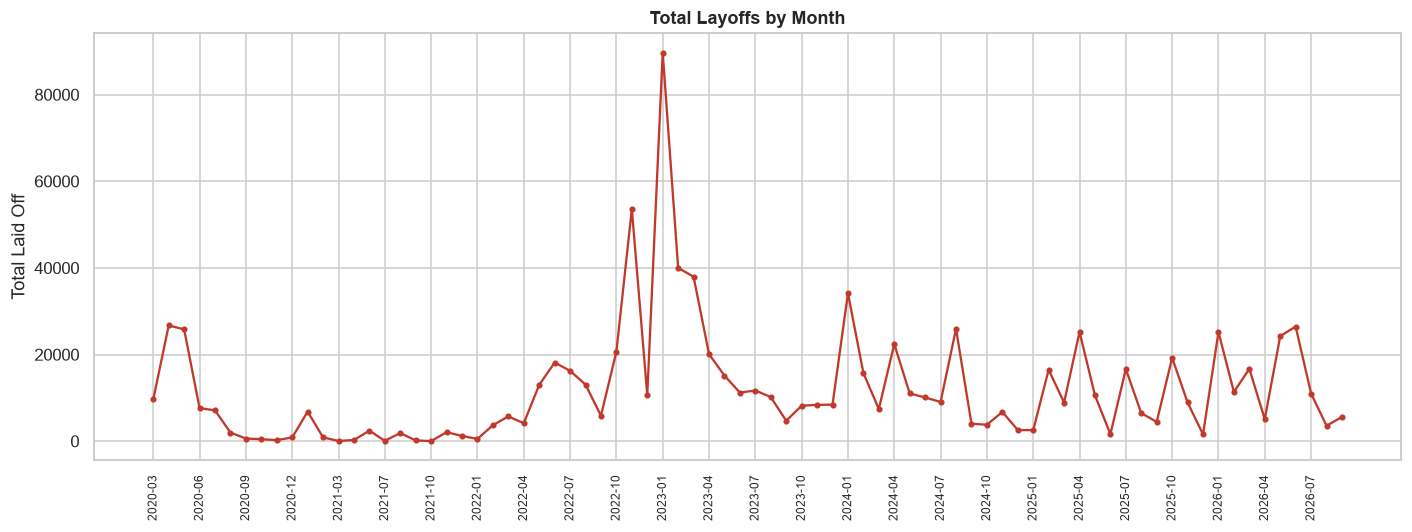

In [13]:
by_month = df.groupby("month")["total_laid_off"].sum()
peak_month = by_month.idxmax()
print(f"Peak month: {peak_month}, total laid off: {by_month.max():,.0f}")

fig, ax = plt.subplots(figsize=(13, 5))
x_labels = by_month.index.astype(str)
ax.plot(x_labels, by_month.values, marker="o", color="#c0392b", linewidth=1.5, markersize=3)

# Only show every 3rd month label so the x-axis stays readable
ax.set_xticks(range(0, len(x_labels), 3))
ax.set_xticklabels(x_labels[::3], rotation=90, ha="center", fontsize=8)

ax.set_title("Total Layoffs by Month", fontweight="bold")
ax.set_ylabel("Total Laid Off")
plt.tight_layout()
plt.savefig("chart2_layoffs_by_month.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 11 :  Mystery question

In [14]:
mystery_candidates = df[df["total_laid_off"].notna() & df["percentage_laid_off"].notna()].copy()

# High % but low total headcount (looks catastrophic by percentage, isn't by real impact)
high_pct_low_total = mystery_candidates[mystery_candidates["total_laid_off"] <= 50].sort_values(
    "percentage_laid_off", ascending=False).head(10)
print(high_pct_low_total[["company", "industry", "total_laid_off", "percentage_laid_off"]])

# High total but genuinely low % (large company, small relative cut)
high_total_low_pct = mystery_candidates[mystery_candidates["percentage_laid_off"] <= 0.10].sort_values(
    "total_laid_off", ascending=False).head(10)
print(high_total_low_pct[["company", "industry", "total_laid_off", "percentage_laid_off"]])

           company   industry  total_laid_off  percentage_laid_off
68         GoLemon     Retail            33.0                  1.0
4602      Help.com    Support            16.0                  1.0
555       Smashing   Consumer             7.0                  1.0
527        Noogata         AI            10.0                  1.0
374     BharatAgri       Food            37.0                  1.0
4517       Amplero  Marketing            17.0                  1.0
4133    Dotscience    Product            10.0                  1.0
4073          Dark    Product             6.0                  1.0
4252    TutorMundi  Education             4.0                  1.0
881   Humble Games      Media            36.0                  1.0
         company        industry  total_laid_off  percentage_laid_off
388       Amazon          Retail         14000.0                 0.01
1036       Tesla  Transportation         14000.0                 0.10
2508      Google        Consumer         12000.0     

### Conclusion

Layoffs are not evenly spread across the tech industry. "Other," Retail, and Hardware absorbed the largest total losses, and January 2023 stands out sharply as the single worst month in the dataset. Percentage laid off and total laid off tell opposite stories at the extremes: small companies can post a 100% layoff rate while affecting only a handful of people, while a 1% cut at Amazon or Google still means thousands of real job losses.

The company (or anyone using this data) should weight total headcount impact, not just percentage, when judging real-world severity, and treat January 2023 as the reference point for what a severe layoff month looks like.

### Business Recommendations

1. Don't rank severity by percentage alone. A 100% layoff at a 6-person startup and a 1% layoff at Amazon are not comparable events; total headcount affected is usually the more meaningful number for real-world impact.

2. Watch Retail and Hardware closely. These industries rank in the top 3 for total layoffs despite not always dominating headlines the way "tech" broadly does.

3. Treat January 2023 as the benchmark for a severe month. At ~89,700 layoffs, it's more than double the next-highest month, useful as a reference point for flagging future spikes early.